# <h1 style="text-align: center; font-weight: bolder;">LAB 6</h1>


**NAME:** Manuel Castillo Obregón

**ID:** u269423

GitHub Labs repository: https://github.com/manueleco/ml-for-sound-and-music.git

Google Colab URL for the lab: https://drive.google.com/file/d/12PSV3WsZU9DG0uIrVPHZQSRoMYx-6DNm/view?usp=sharing

# <h2 style="text-align: center; font-weight: bolder;">SETUP</h2>


* The notebook was executed in a remote server (Modal) so a try catch was implemented so we could decide about resources and paths depending on the environment: MacBook with M1 chip, Google Colab, Modal or any PC with Cuda (nvidia) cores available to use the GPU to its maximum.
* Installed the required dependencies for PyTorch training, audio I/O, visualization, perceptual/spectral losses, and CO2 tracking.
* Detected the available backend (CUDA or MPS or CPU) and set random seedsto make it global.
* Defined the main experiment params: 16 kHz sample rate and fixed 1 second clips (16,000 samples) to keep training consistent and efficient.


In [1]:
import os, sys, zipfile, random, time, pathlib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio

try:
    import soundfile as sf
except Exception:
    !pip -q install soundfile
    import soundfile as sf

from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import trange
from pathlib import Path

try:
    from codecarbon import EmissionsTracker
    USE_CODECARBON = True
except Exception:
    !pip -q install codecarbon
    from codecarbon import EmissionsTracker
    USE_CODECARBON = True

CODECARBON_DIR = Path("./codecarbon_logs")
CODECARBON_DIR.mkdir(parents=True, exist_ok=True)

try:
    import psutil
    USE_PSUTIL = True
except Exception:
    !pip -q install psutil
    import psutil
    USE_PSUTIL = True

import subprocess

print("PWD:", pathlib.Path().resolve())
print("Root:", list(pathlib.Path("/mnt").glob("*")))

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("Device:", device)

torch.set_num_threads(max(1, (os.cpu_count() or 4) - 1))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device == "cuda":
    torch.cuda.manual_seed_all(SEED)

SAMPLE_RATE = 16000
TARGET_LENGTH = 16000
BATCH_SIZE = 64
N_EPOCHS = 50
N_EPOCHS_PERC = 50

DATA_ROOT = None

proc = psutil.Process(os.getpid()) if USE_PSUTIL else None

def _bytes_to_gb(x):
    return float(x) / (1024**3)

def get_cpu_ram():
    if proc is None:
        return None, None
    try:
        cpu = psutil.cpu_percent(interval=None)
        rss = _bytes_to_gb(proc.memory_info().rss)
        return float(cpu), float(rss)
    except Exception:
        return None, None

def get_gpu_mem():
    if device != "cuda":
        return None, None
    try:
        alloc = _bytes_to_gb(torch.cuda.memory_allocated())
        peak = _bytes_to_gb(torch.cuda.max_memory_allocated())
        return float(alloc), float(peak)
    except Exception:
        return None, None


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
PWD: /root
Root: [PosixPath('/mnt/mtat-datalabs')]
Device: cuda


# <h2 style="text-align: center; font-weight: bolder;">DATA LOADING WITH MAGNATAGATUNE</h2>


Reutilizamos parcialmente el codigo del lab anterior

En lab 5 ya teniamos: 
- Mirdata initialize
- Un dataset
- Segmentación



Implemented a robust loading strategy that works across environments:
* Modal Volume (if the dataset is mounted at /mnt/mtat-datalabs)
* mirdata (if the dataset is available in the installed mirdata version)
* Local fallback (searching for annotations_final.csv and clip_info_final.csv)


Summary: Built train/validation/test splits (80/10/10) and optionally capped the number of examples to control training time and cost (mainly when in need for it to execute fast)

In [2]:
# intento de carga con mirdata y fallback a versión local o modal

USE_MIRDATA = False

# detectar Modal

IS_MODAL = bool(os.environ.get("MODAL_TASK_ID") or os.environ.get("MODAL_ENVIRONMENT") or os.environ.get("MODAL_RUN_ID"))
# ruta real modal
MODAL_VOLUME_ROOT = Path("/mnt/mtat-datalabs")

def read_csv_flexible(path):
    try:
        return pd.read_csv(path, sep="\t")
    except Exception:
        return pd.read_csv(path, sep=",")

def make_splits_from_dfs(df_ann, df_info, audio_root, max_tracks=10000):
    df_ann.columns = [c.strip() for c in df_ann.columns]
    df_info.columns = [c.strip() for c in df_info.columns]

    if "clip_id" not in df_ann.columns:
        raise ValueError(f"annotations_final.csv missing 'clip_id'. Columns: {list(df_ann.columns)[:20]}")

    if "clip_id" not in df_info.columns or "mp3_path" not in df_info.columns:
        raise ValueError(f"clip_info_final.csv must contain 'clip_id' and 'mp3_path'. Columns: {list(df_info.columns)[:20]}")

    all_ids = df_ann["clip_id"].values
    if len(all_ids) > max_tracks:
        all_ids = all_ids[:max_tracks]

    all_ids = list(all_ids)
    random.shuffle(all_ids)

    n_total = len(all_ids)
    n_train = int(0.8 * n_total)
    n_val = int(0.1 * n_total)

    train_ids = all_ids[:n_train]
    val_ids = all_ids[n_train:n_train + n_val]
    test_ids = all_ids[n_train + n_val:]

    df_info_indexed = df_info.set_index("clip_id")

    def make_df(id_list):
        rows = []
        for cid in id_list:
            if cid in df_info_indexed.index:
                rows.append({"clip_id": cid, "mp3_path": df_info_indexed.loc[cid, "mp3_path"]})
        return pd.DataFrame(rows)

    train_df = make_df(train_ids)
    val_df = make_df(val_ids)
    test_df = make_df(test_ids)

    return train_df, val_df, test_df, Path(audio_root)

if IS_MODAL and (MODAL_VOLUME_ROOT / "annotations_final.csv").exists():
    data_dir = str(MODAL_VOLUME_ROOT)
    ann_path = os.path.join(data_dir, "annotations_final.csv")
    info_path = os.path.join(data_dir, "clip_info_final.csv")

    # normalizar nombres de columnas por si vienen raros

    df_ann = read_csv_flexible(ann_path)
    df_info = read_csv_flexible(info_path)

    audio_root = os.path.join(data_dir, "audio")
    train_df, val_df, test_df, DATA_ROOT = make_splits_from_dfs(df_ann, df_info, audio_root)

    print("Using MagnaTagATune from Modal Volume.")
    print("Sizes (train, val, test):", len(train_df), len(val_df), len(test_df))
    print("DATA_ROOT:", DATA_ROOT)

else:
    try:
        import mirdata

        # algunos installs de mirdata no traen magnatagatune entonces si falla lo llevo al except

        data_home = os.environ.get("MTAT_MIRDATA_HOME", "./data/mtat")
        mtat = mirdata.initialize("magnatagatune", data_home=data_home)
        mtat.download()
        mtat.validate()

        all_tracks_dict = mtat.load_tracks()
        all_tracks = list(all_tracks_dict.values())
        random.shuffle(all_tracks)

        n_total = len(all_tracks)
        n_train = int(0.8 * n_total)
        n_val = int(0.1 * n_total)

        train_tracks = all_tracks[:n_train]
        val_tracks = all_tracks[n_train:n_train + n_val]
        test_tracks = all_tracks[n_train + n_val:]

        USE_MIRDATA = True
        print("Using MagnaTagATune via mirdata.")
        print("Sizes (train, val, test):", len(train_tracks), len(val_tracks), len(test_tracks))

    except Exception as e:
        print("mirdata not available or dataset not supported in this mirdata install. Falling back to local dataset.")
        print("Detail:", e)

        IN_COLAB = "google.colab" in sys.modules
        if IN_COLAB:
            from google.colab import drive
            drive.mount("/content/drive")
            search_roots = [Path("/content/drive/MyDrive"), Path("/content")]
        else:
            search_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]

        data_path = None
        for root in search_roots:
            if root.exists():
                for p in root.rglob("annotations_final.csv"):
                    data_path = p.parent
                    break
            if data_path is not None:
                break

        if data_path is None:
            raise FileNotFoundError("Could not find annotations_final.csv in known locations")

        data_dir = str(data_path)
        ann_path = os.path.join(data_dir, "annotations_final.csv")
        info_path = os.path.join(data_dir, "clip_info_final.csv")

        df_ann = read_csv_flexible(ann_path)
        df_info = read_csv_flexible(info_path)

        audio_root = os.path.join(data_dir, "audio")
        os.makedirs(audio_root, exist_ok=True)

        full_zip = os.path.join(data_dir, "mp3_full.zip")
        if os.path.exists(full_zip) and not os.path.exists(os.path.join(audio_root, "000")):
            with zipfile.ZipFile(full_zip, "r") as z:
                z.extractall(audio_root)

        train_df, val_df, test_df, DATA_ROOT = make_splits_from_dfs(df_ann, df_info, audio_root)

        print("Using local MagnaTagATune.")
        print("Sizes (train, val, test):", len(train_df), len(val_df), len(test_df))
        print("DATA_ROOT:", DATA_ROOT)

mirdata not available or dataset not supported in this mirdata install. Falling back to local dataset.
Detail: No module named 'mirdata'
Using local MagnaTagATune.
Sizes (train, val, test): 8000 1000 1000
DATA_ROOT: /__modal/volumes/vo-IDPx0DuUwAPUOrIsswHOuI/datalabs/audio


Dataset para encoder

# <h2 style="text-align: center; font-weight: bolder;">AUTOENCODER BASELINE (MSE)</h2>


**Autoencoder convolucional**

Implemented a 1D convolutional autoencoder:
* Encoder with 3 Conv 1D layers (stride=2) to progressively downsample the waveform.
* Fixed size fully connected bottleneck of 512 (compression rate unchanged as required).
* Decoder with ConvTranspose1D layers to reconstruct the waveform back to the original length.

Trained a baseline model using MSE loss to obtain a quantitative reference and reconstruction baseline you can trust in time domain.

In [ ]:
# dataset para autoencoder (mirdata)
class MTATAutoencoderDatasetMirdata(Dataset):
    def __init__(self, tracks, split="train"):
        self.tracks = tracks
        self.split = split

    def __len__(self):
        return len(self.tracks)

    def __getitem__(self, idx):
        # carga de datos
        track = self.tracks[idx]
        audio, sr = track.audio

        # conversión a tensor
        audio = torch.tensor(audio, dtype=torch.float32)

        # conversion a mono
        if audio.ndim > 1:
            audio = audio.mean(dim=0)

        # resample
        if sr != SAMPLE_RATE:
            audio = torchaudio.functional.resample(
                audio.unsqueeze(0),
                orig_freq=sr,
                new_freq=SAMPLE_RATE
            ).squeeze(0)

        # tratamiento de audio largo (como seccion 2)
        audio = self._crop_or_pad(audio)

        return {"audio": audio}

    def _crop_or_pad(self, audio):
        length = audio.shape[-1]
        if length > TARGET_LENGTH:
            if self.split == "train":
                start = random.randint(0, length - TARGET_LENGTH)
            else:
                start = (length - TARGET_LENGTH) // 2
            audio = audio[start:start + TARGET_LENGTH]
        elif length < TARGET_LENGTH:
            pad = TARGET_LENGTH - length
            audio = F.pad(audio, (0, pad))
        return audio



# dataset para autoencoder (local: CSV + mp3)
class MTATAutoencoderDatasetLocal(Dataset):
    def __init__(self, df, split="train", data_root=None):
        self.df = df.reset_index(drop=True)
        self.split = split
        self.data_root = Path(data_root) if data_root is not None else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # carga de datos
        row = self.df.iloc[idx]
        mp3_rel = str(row["mp3_path"])

        # normalización de ruta (evita duplicaciones)
        if mp3_rel.startswith("audio/"):
            mp3_rel = mp3_rel[len("audio/"):]

        audio_path = self.data_root / mp3_rel

        # lectura de audio (evita torchcodec/ffmpeg)
        # (T, C)
        audio_np, sr = sf.read(str(audio_path), always_2d=True)  

        # conversión a tensor (C, T)
        audio = torch.tensor(audio_np, dtype=torch.float32).T

        # conversion a mono
        if audio.size(0) > 1:
            audio = audio.mean(dim=0, keepdim=True)

        # resample
        if sr != SAMPLE_RATE:
            audio = torchaudio.functional.resample(
                audio,
                orig_freq=sr,
                new_freq=SAMPLE_RATE
            )
            sr = SAMPLE_RATE

        audio = audio.squeeze(0)

        # tratamiento de audio largo (como seccion 2)
        audio = self._crop_or_pad(audio)

        return {"audio": audio}

    def _crop_or_pad(self, audio):
        length = audio.shape[-1]
        if length > TARGET_LENGTH:
            if self.split == "train":
                start = random.randint(0, length - TARGET_LENGTH)
            else:
                start = (length - TARGET_LENGTH) // 2
            audio = audio[start:start + TARGET_LENGTH]
        elif length < TARGET_LENGTH:
            pad = TARGET_LENGTH - length
            audio = F.pad(audio, (0, pad))
        return audio


# creación de datasets y dataloaders
if USE_MIRDATA:
    train_dataset = MTATAutoencoderDatasetMirdata(train_tracks, split="train")
    val_dataset   = MTATAutoencoderDatasetMirdata(val_tracks,   split="val")
    test_dataset  = MTATAutoencoderDatasetMirdata(test_tracks,  split="test")
else:
    if DATA_ROOT is None:
        raise ValueError("DATA_ROOT no está definido en fallback local")
    train_dataset = MTATAutoencoderDatasetLocal(train_df, split="train", data_root=DATA_ROOT)
    val_dataset   = MTATAutoencoderDatasetLocal(val_df,   split="valid", data_root=DATA_ROOT)
    test_dataset  = MTATAutoencoderDatasetLocal(test_df,  split="test",  data_root=DATA_ROOT)
import os


import platform

IS_MACOS = (platform.system().lower() == "darwin")

if IS_MACOS:
    NUM_WORKERS = 0
else:
    NUM_WORKERS = min(8, (os.cpu_count() or 8))

pin_memory = (device == "cuda")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=2 if NUM_WORKERS > 0 else None
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=2 if NUM_WORKERS > 0 else None
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=2 if NUM_WORKERS > 0 else None
)

print("DataLoaders listos:")
print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))
print("Test batches: ", len(test_loader))
print("NUM_WORKERS:", NUM_WORKERS)

t0 = time.time()
_ = next(iter(train_loader))
print("Tiempo para 1 batch:", time.time() - t0, "sec")

DataLoaders listos:
Train batches: 125
Val batches:   16
Test batches:  16
NUM_WORKERS: 8
Tiempo para 1 batch: 3.0653979778289795 sec


In [4]:
# perceptual / spectral loss (auraloss con fallback)
mse_loss = nn.MSELoss()

USE_AURALOSS = False
try:
    import auraloss
    mrstft = auraloss.freq.MultiResolutionSTFTLoss(
        fft_sizes=[512, 1024, 2048],
        hop_sizes=[128, 256, 512],
        win_lengths=[512, 1024, 2048]
    ).to(device)
    USE_AURALOSS = True

    def perceptual_loss(x_rec, x):
        return mrstft(x_rec, x)

except Exception:
    def multi_scale_stft_loss(x, y, scales=(512, 1024, 2048), hop_ratio=0.25, eps=1e-7):
        loss = 0.0
        for n_fft in scales:
            hop = int(n_fft * hop_ratio)
            window = torch.hann_window(n_fft, device=x.device)
            X = torch.stft(x.squeeze(1), n_fft=n_fft, hop_length=hop, window=window, return_complex=True)
            Y = torch.stft(y.squeeze(1), n_fft=n_fft, hop_length=hop, window=window, return_complex=True)
            Xmag = torch.log(X.abs() + eps)
            Ymag = torch.log(Y.abs() + eps)
            loss += torch.mean(torch.abs(Xmag - Ymag))
        return loss / len(scales)

    def perceptual_loss(x_rec, x):
        return multi_scale_stft_loss(x_rec, x)

def combined_loss(x_rec, x, alpha=0.01):
    l_mse = mse_loss(x_rec, x)
    l_stft = perceptual_loss(x_rec, x)
    return l_mse + alpha * l_stft, l_mse, l_stft

print("Perceptual loss:", "auraloss MRSTFT" if USE_AURALOSS else "manual multi-scale STFT")

Perceptual loss: manual multi-scale STFT


In [5]:
# autoencoder convolucional
class AudioAutoencoder(nn.Module):
    def __init__(self, input_length=TARGET_LENGTH, bottleneck_size=512):
        super().__init__()
        self.input_length = input_length
        self.bottleneck_size = bottleneck_size

        # encoder
        self.enc_conv1 = nn.Conv1d(1, 16, kernel_size=9, stride=2, padding=4)
        self.enc_conv2 = nn.Conv1d(16, 32, kernel_size=9, stride=2, padding=4)
        self.enc_conv3 = nn.Conv1d(32, 64, kernel_size=9, stride=2, padding=4)

        length_after = input_length
        for _ in range(3):
            length_after = int(np.ceil(length_after / 2))

        self.flatten_dim = 64 * length_after

        # bottleneck (NO cambio compresión segun dice las instrucciones)
        self.fc_enc = nn.Linear(self.flatten_dim, bottleneck_size)
        self.fc_dec = nn.Linear(bottleneck_size, self.flatten_dim)

        # decoder
        self.dec_conv1 = nn.ConvTranspose1d(64, 32, kernel_size=9, stride=2, padding=4, output_padding=1)
        self.dec_conv2 = nn.ConvTranspose1d(32, 16, kernel_size=9, stride=2, padding=4, output_padding=1)
        self.dec_conv3 = nn.ConvTranspose1d(16, 1,  kernel_size=9, stride=2, padding=4, output_padding=1)

    def encode(self, x):
        x = F.relu(self.enc_conv1(x))
        x = F.relu(self.enc_conv2(x))
        x = F.relu(self.enc_conv3(x))
        x = x.flatten(start_dim=1)
        z = self.fc_enc(x)
        return z

    def decode(self, z):
        x = self.fc_dec(z)
        x = x.view(x.size(0), 64, -1)
        x = F.relu(self.dec_conv1(x))
        x = F.relu(self.dec_conv2(x))
        x = self.dec_conv3(x)
        x = x[..., :self.input_length]
        return x

    def forward(self, x):
        z = self.encode(x)
        x_rec = self.decode(z)
        return x_rec, z

#  check
tmp = AudioAutoencoder(input_length=TARGET_LENGTH, bottleneck_size=512).to(device)
n_params = sum(p.numel() for p in tmp.parameters() if p.requires_grad)
print("AudioAutoencoder listo. Params:", f"{n_params:,}")
del tmp

AudioAutoencoder listo. Params: 131,247,041


In [6]:
from tqdm.auto import tqdm

def train_autoencoder(
    model,
    train_loader,
    val_loader,
    n_epochs=N_EPOCHS,
    lr=1e-3,
    use_perceptual=False,
    alpha=0.1,
    project_name="lab6_autoencoder"
):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    val_mse_list = []
    val_stft_list = []

    cpu_pct_per_epoch = []
    ram_gb_per_epoch = []
    gpu_alloc_gb_per_epoch = []
    gpu_peak_gb_per_epoch = []

    if device == "cuda":
        try:
            torch.cuda.reset_peak_memory_stats()
        except Exception:
            pass

    try:
        tracker = EmissionsTracker(project_name=project_name, log_level="error", save_to_file=True)
        tracker.start()
    except Exception:
        tracker = None

    t_global = time.time()

    pbar_epoch = tqdm(range(n_epochs), desc="Epochs", unit="epoch")
    for epoch in pbar_epoch:
        model.train()
        batch_train_losses = []

        pbar_batch = tqdm(train_loader, desc=f"Train {epoch+1}/{n_epochs}", unit="batch", leave=False)
        for batch in pbar_batch:
            x = batch["audio"].to(device, non_blocking=True).unsqueeze(1)

            optimizer.zero_grad(set_to_none=True)
            x_rec, _ = model(x)

            if use_perceptual:
                loss, _, _ = combined_loss(x_rec, x, alpha=alpha)
            else:
                loss = mse_loss(x_rec, x)

            loss.backward()
            optimizer.step()

            batch_train_losses.append(loss.item())
            pbar_batch.set_postfix({"loss": f"{loss.item():.5f}"})

        epoch_train = float(np.mean(batch_train_losses))
        train_losses.append(epoch_train)

        model.eval()
        batch_val_losses = []
        batch_val_mse = []
        batch_val_stft = []

        with torch.no_grad():
            pbar_val = tqdm(val_loader, desc=f"Val {epoch+1}/{n_epochs}", unit="batch", leave=False)
            for batch in pbar_val:
                x = batch["audio"].to(device, non_blocking=True).unsqueeze(1)
                x_rec, _ = model(x)

                v_mse = mse_loss(x_rec, x)
                batch_val_mse.append(v_mse.item())

                if use_perceptual:
                    v_loss, _, v_stft = combined_loss(x_rec, x, alpha=alpha)
                    batch_val_losses.append(v_loss.item())
                    batch_val_stft.append(v_stft.item())
                    pbar_val.set_postfix({"stft": f"{v_stft.item():.5f}", "mse": f"{v_mse.item():.5f}"})
                else:
                    batch_val_losses.append(v_mse.item())
                    pbar_val.set_postfix({"mse": f"{v_mse.item():.5f}"})

        epoch_val = float(np.mean(batch_val_losses))
        epoch_val_mse = float(np.mean(batch_val_mse))
        val_losses.append(epoch_val)
        val_mse_list.append(epoch_val_mse)

        if len(batch_val_stft) > 0:
            val_stft_list.append(float(np.mean(batch_val_stft)))

        cpu_pct, ram_gb = get_cpu_ram()
        gpu_alloc_gb, gpu_peak_gb = get_gpu_mem()

        cpu_pct_per_epoch.append(cpu_pct)
        ram_gb_per_epoch.append(ram_gb)
        gpu_alloc_gb_per_epoch.append(gpu_alloc_gb)
        gpu_peak_gb_per_epoch.append(gpu_peak_gb)

        postfix = {
            "train": f"{epoch_train:.5f}",
            "val_mse": f"{epoch_val_mse:.5f}",
            "sec": f"{time.time()-t_global:.1f}"
        }
        if cpu_pct is not None:
            postfix["cpu%"] = f"{cpu_pct:.1f}"
        if ram_gb is not None:
            postfix["ramGB"] = f"{ram_gb:.2f}"
        if gpu_peak_gb is not None:
            postfix["gpuGB"] = f"{gpu_peak_gb:.2f}"

        pbar_epoch.set_postfix(postfix)

        print(f"[{epoch+1}/{n_epochs}] train={epoch_train:.6f} val_mse={epoch_val_mse:.6f}")

    emissions_kg = None
    if tracker is not None:
        try:
            emissions_kg = tracker.stop()
        except Exception:
            emissions_kg = None

    total_time_sec = time.time() - t_global

    def _safe_max(xs):
        xs2 = [x for x in xs if x is not None]
        return float(max(xs2)) if len(xs2) > 0 else None

    def _safe_mean(xs):
        xs2 = [x for x in xs if x is not None]
        return float(np.mean(xs2)) if len(xs2) > 0 else None

    return model, {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_mse": val_mse_list,
        "val_stft": val_stft_list if len(val_stft_list) > 0 else None,
        "emissions_kg": emissions_kg,
        "time_sec": total_time_sec,
        "time_min": total_time_sec / 60.0,
        "cpu_pct_per_epoch": cpu_pct_per_epoch,
        "ram_gb_per_epoch": ram_gb_per_epoch,
        "gpu_alloc_gb_per_epoch": gpu_alloc_gb_per_epoch,
        "gpu_peak_gb_per_epoch": gpu_peak_gb_per_epoch,
        "cpu_pct_mean": _safe_mean(cpu_pct_per_epoch),
        "ram_gb_max": _safe_max(ram_gb_per_epoch),
        "gpu_peak_gb_max": _safe_max(gpu_peak_gb_per_epoch)
    }

# <h3 style="text-align: left; font-weight: bolder;">MSE</h3>


In [7]:
model_mse = AudioAutoencoder(input_length=TARGET_LENGTH, bottleneck_size=512).to(device)

model_mse, results_mse = train_autoencoder(
    model=model_mse,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=N_EPOCHS,
    lr=1e-3,
    use_perceptual=False,
    project_name="lab6_autoencoder_mse"
)

results_mse

[codecarbon WARNING @ 21:30:48] Multiple instances of codecarbon are allowed to run at the same time.


Epochs:   0%|          | 0/50 [00:00<?, ?epoch/s]

Train 1/50:   0%|          | 0/125 [00:00<?, ?batch/s]

Val 1/50:   0%|          | 0/16 [00:00<?, ?batch/s]

[1/50] train=0.027414 val_mse=0.026258


...

[49/50] train=0.009232 val_mse=0.009752


Train 50/50:   0%|          | 0/125 [00:00<?, ?batch/s]

Val 50/50:   0%|          | 0/16 [00:00<?, ?batch/s]

[50/50] train=0.009312 val_mse=0.009721


{'train_losses': [0.027414493784308432,
  0.025808982238173486,
  0.0254068214148283,
  0.025726541608572007,
  0.025501589357852936,
  0.025787205070257186,
  0.025591293618083,
  0.025518696635961534,
  0.020486917652189733,
  0.016054672844707966,
  0.0144040150269866,
  0.013256860964000226,
  0.012264372192323209,
  0.011598310731351376,
  0.010928223602473737,
  0.010454051118344068,
  0.010166543018072844,
  0.0099106704890728,
  0.009611368242651224,
  0.009620366096496582,
  0.009436018712818623,
  0.009578241605311632,
  0.009420419551432132,
  0.009352432645857334,
  0.009426791965961457,
  0.009427657671272755,
  0.009336283586919307,
  0.00951588759571314,
  0.00934824739769101,
  0.009307001303881407,
  0.00937482576817274,
  0.00944596491754055,
  0.009376528203487396,
  0.009256017211824655,
  0.00924240317568183,
  0.009331049121916294,
  0.00923364669829607,
  0.009394901782274246,
  0.009347875151783229,
  0.009166838001459838,
  0.009385482598096132,
  0.00932595721

In [8]:
#N_EPOCHS = 8

# <h3 style="text-align: left; font-weight: bolder;">PERCEPTUAL LOSS</h3>


In [9]:
# entrenamiento con perdida perceptual
model_perc = AudioAutoencoder(
    input_length=TARGET_LENGTH,
    bottleneck_size=512
).to(device)

model_perc, results_perc = train_autoencoder(
    model=model_perc,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=N_EPOCHS_PERC,
    lr=1e-3,
    use_perceptual=True,
    alpha=0.01,
    project_name="lab6_autoencoder_perc"
)

results_perc

Epochs:   0%|          | 0/50 [00:00<?, ?epoch/s]

Train 1/50:   0%|          | 0/125 [00:00<?, ?batch/s]

Val 1/50:   0%|          | 0/16 [00:00<?, ?batch/s]

[1/50] train=0.050706 val_mse=0.026619


Train 2/50:   0%|          | 0/125 [00:00<?, ?batch/s]

...

[49/50] train=0.029746 val_mse=0.015680


Train 50/50:   0%|          | 0/125 [00:00<?, ?batch/s]

Val 50/50:   0%|          | 0/16 [00:00<?, ?batch/s]

[50/50] train=0.029886 val_mse=0.015000


{'train_losses': [0.05070576685667038,
  0.04470826658606529,
  0.04384464678168297,
  0.04363788694143295,
  0.04305954357981682,
  0.04275560063123703,
  0.042555079907178876,
  0.042243849337100986,
  0.041955887347459794,
  0.042068235516548154,
  0.041752717554569246,
  0.0422988628745079,
  0.041581294298172,
  0.04180631789565086,
  0.042043171644210814,
  0.04187474715709686,
  0.042100871324539185,
  0.041968854248523715,
  0.04120091986656189,
  0.041032600939273835,
  0.04151313552260399,
  0.04142932713031769,
  0.042222670286893846,
  0.04116638994216919,
  0.04100255334377289,
  0.041549159467220306,
  0.040938580453395844,
  0.040762513905763624,
  0.03920517873764038,
  0.03757664576172828,
  0.037880094900727274,
  0.0361939769089222,
  0.035117330998182296,
  0.03438759118318558,
  0.034515844896435735,
  0.03347264228761196,
  0.03324093696475029,
  0.03218676620721817,
  0.03192260609567165,
  0.03181678558886051,
  0.03164972347021103,
  0.03128816711902618,
  0.03

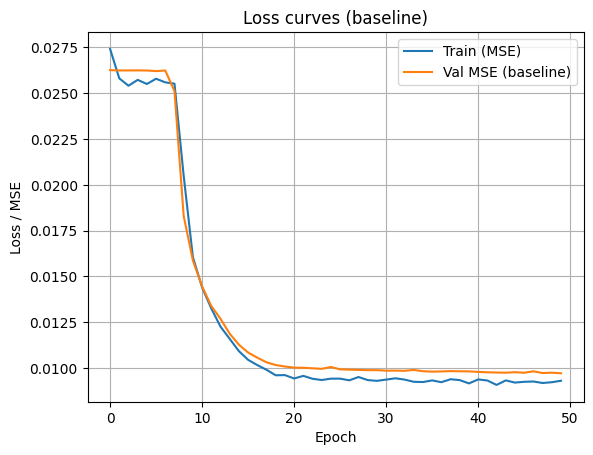

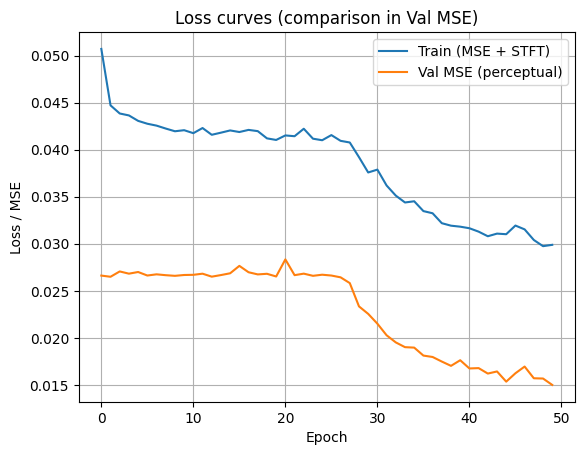

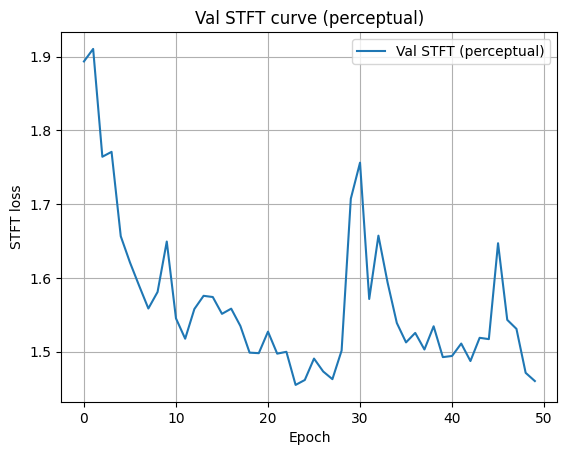

In [10]:


# grafica de perdidas

plt.figure()
plt.plot(results_mse["train_losses"], label="Train (MSE)")
plt.plot(results_mse["val_mse"], label="Val MSE (baseline)")
plt.xlabel("Epoch")
plt.ylabel("Loss / MSE")
plt.legend()
plt.title("Loss curves (baseline)")
plt.grid(True)
plt.show()

if "results_perc" in globals():
    plt.figure()
    plt.plot(results_perc["train_losses"], label="Train (MSE + STFT)")
    plt.plot(results_perc["val_mse"], label="Val MSE (perceptual)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss / MSE")
    plt.legend()
    plt.title("Loss curves (comparison in Val MSE)")
    plt.grid(True)
    plt.show()
  
    # grafica extra: solo para ver STFT val del perceptual

    if results_perc["val_stft"] is not None:
        plt.figure()
        plt.plot(results_perc["val_stft"], label="Val STFT (perceptual)")
        plt.xlabel("Epoch")
        plt.ylabel("STFT loss")
        plt.legend()
        plt.title("Val STFT curve (perceptual)")
        plt.grid(True)
        plt.show()

# <h2 style="text-align: center; font-weight: bolder;">QUANTITATIVE PERFRMANCE</h2>

The algorithm/model based on MSE achieves a lower reconstruction error, in terms of sample wise loss (as expected, due to its optimization objective).
The perceptual loss model doesn't outperform the baseline in MSE metrics but it achieves lower perceptual loss values (multi resolution STFT). This indicates an improved spectral similarity between original and reconstructed signals.

These results highight the trade off between waveform accuracy and percetual quality in audio reconstrution tasks.



**_WAVEFORM PLOTTING_**

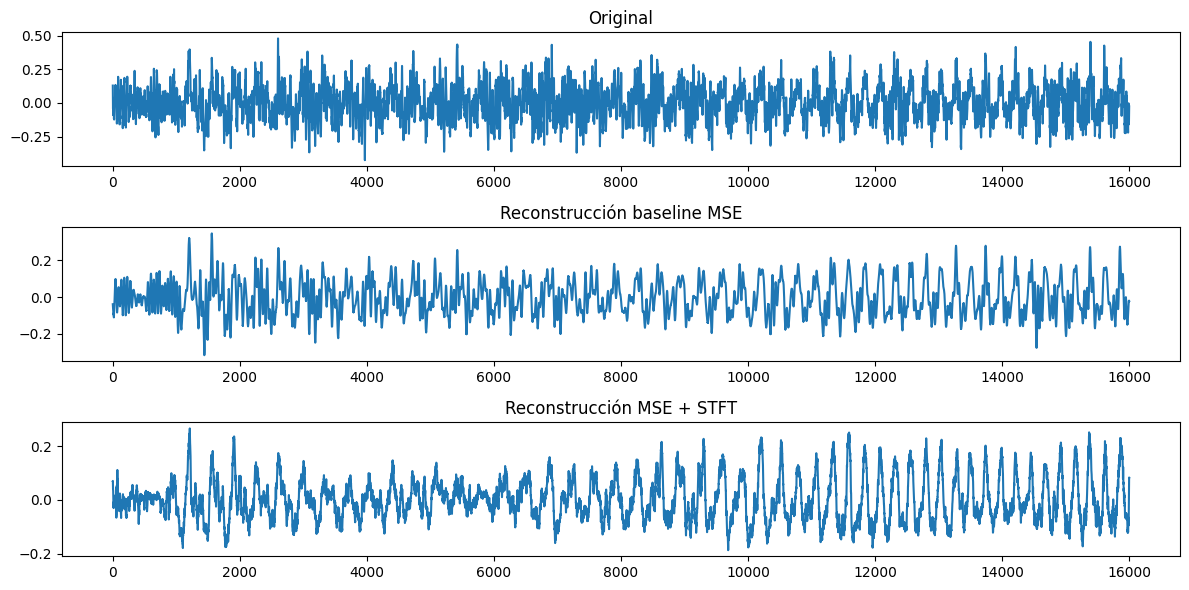

In [ ]:
from IPython.display import Audio, display

batch = next(iter(test_loader))
x = batch["audio"][:4].float().to(device).unsqueeze(1)

model_mse.eval()
model_perc.eval()

with torch.no_grad():
    x_rec_mse, _ = model_mse(x)
    x_rec_perc, _ = model_perc(x)

# waveform original vs reconstruida
idx = 0
orig = x[idx].detach().cpu().squeeze().numpy()
rec_mse = x_rec_mse[idx].detach().cpu().squeeze().numpy()
rec_perc = x_rec_perc[idx].detach().cpu().squeeze().numpy()

plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(orig)
plt.title("Original")

plt.subplot(3, 1, 2)
plt.plot(rec_mse)
plt.title("Reconstrucción baseline MSE")

plt.subplot(3, 1, 3)
plt.plot(rec_perc)
plt.title("Reconstrucción MSE + STFT")
plt.tight_layout()
plt.show()



**_12 EXAMPLES FOR ANALYSIS_**

In [12]:
from IPython.display import Audio, display
import numpy as np
import torch

def rms(x, eps=1e-8):
    return np.sqrt(np.mean(x**2) + eps)

def match_rms(y, ref, eps=1e-8):
    ry = rms(y, eps)
    rr = rms(ref, eps)
    return y * (rr / (ry + eps))

def to_audio(x_t):
    return x_t.detach().cpu().squeeze().numpy()

def show_examples(model_a, model_b, loader, n=12, seed=0):
    g = torch.Generator()
    g.manual_seed(seed)

    model_a.eval()
    model_b.eval()

    batch = next(iter(loader))
    x = batch["audio"].float()

    if x.shape[0] < n:
        n = x.shape[0]

    idxs = torch.randperm(x.shape[0], generator=g)[:n].tolist()
    x_sel = x[idxs].to(device).unsqueeze(1)

    with torch.no_grad():
        ra, _ = model_a(x_sel)
        rb, _ = model_b(x_sel)

    for i in range(n):
        orig = to_audio(x_sel[i])
        a = to_audio(ra[i])
        b = to_audio(rb[i])

        a = match_rms(a, orig)
        b = match_rms(b, orig)

        a = np.clip(a, -1.0, 1.0)
        b = np.clip(b, -1.0, 1.0)

        print(f"Example {i+1}/{n}")
        print("Original:")
        display(Audio(orig, rate=SAMPLE_RATE))
        print("Recon (MSE):")
        display(Audio(a, rate=SAMPLE_RATE))
        print("Recon (Perceptual):")
        display(Audio(b, rate=SAMPLE_RATE))
        print("-" * 60)

show_examples(model_mse, model_perc, test_loader, n=12, seed=42)

Example 1/12
Original:


Recon (MSE):


Recon (Perceptual):


------------------------------------------------------------
Example 2/12
Original:


Recon (MSE):


...

Recon (Perceptual):


------------------------------------------------------------
Example 12/12
Original:


Recon (MSE):


Recon (Perceptual):


------------------------------------------------------------


# <h2 style="text-align: center; font-weight: bolder;">ABOUT THE TECHNIQUES USED IN THIS LAB</h2>


# <h3 style="text-align: left; font-weight: bolder;">LONG AUDIOS STRATEGY</h3>


Handled variable and length audio by enforcing a fixed input length (1 second):
* Training: random crop (seeking to add temporal augmentation and improve generalization).
* Validation/Test: centered crop (to ensure consistent evaluation).

This strategy is expected to allow training the model on MTAT clips with different durations while keeping batch shapes fixed.

# <h3 style="text-align: left; font-weight: bolder;">RECONSTRUCTION IMPROVEMENT (PERCEPTUAL LOSS)</h3>


* Trained a second model using a perceptual loss based on multi resolution STFT trying to combine it with MSE.
* The goal is to improve perceived spectral quality of reconstructions (timbre, detail), even if there's not a notable improvement in MSE.

## <h2 style="text-align: center; font-weight: bolder;">AUDIO RECONSTRUCTION RESULTS</h2>

The baseline autoencoder trained with MSE produces reconstructions that can be considered indetifiable and preserves overall a temporal structure (and rhythm) of the original audio.

However, the reconstructed signals sound perceptually muffled, with reduced brightness and less defined transients which translates to a boxed or damped audio character.

In contrast, the perceptual-loss model emphasizes low frequency energy and rhytmic components. The reconstructed audio preserves bass content and structures with identifiable beat in a more effective way; all of this despite high frequency details and spectral brightness remains attenuated. This behavior, reflects the trend for spectral loss to prioritize global spectral similarity over temporal details.

# <h2 style="text-align: center; font-weight: bolder;">RESULTS, DICUSSION, RESOURCES AND CONCLUSION</h2>


* In the notebook you can find: reported training and validation curves and compared both models using a common metric (Validation MSE).
* For the perceptual model, also tracked the validation perceptual/STFT loss, mainly as an auxiliary metric.
* Measured total training time and estimated CO2 emissions using CodeCarbon for resource (and) environmental reporting.

In [13]:
# resumen final de resultados y emisiones
def print_summary(name, res):
    print(f"=== {name} ===")

    # métrica comparable entre modelos
    if "val_mse" in res and res["val_mse"] is not None:
        print(f"Best Val MSE:  {min(res['val_mse']):.6f}")

    # métrica perceptual (solo aplica si existe)
    if "val_stft" in res and res["val_stft"] is not None:
        print(f"Best Val STFT: {min(res['val_stft']):.6f}")

    print(f"Total time:  {res['time_min']:.2f} min")
    print(f"Total CO2 Emissions: {res['emissions_kg']:.6f} kg")
    print()

print_summary("Baseline MSE", results_mse)
print_summary("MSE + STFT",   results_perc)


print("CPU mean (%):", results_mse.get("cpu_pct_mean"), "| RAM max (GB):", results_mse.get("ram_gb_max"), "| GPU peak (GB):", results_mse.get("gpu_peak_gb_max"))
print("CPU mean (%):", results_perc.get("cpu_pct_mean"), "| RAM max (GB):", results_perc.get("ram_gb_max"), "| GPU peak (GB):", results_perc.get("gpu_peak_gb_max"))

=== Baseline MSE ===
Best Val MSE:  0.009721
Total time:  35.15 min
Total CO2 Emissions: 0.045078 kg

=== MSE + STFT ===
Best Val MSE:  0.015000
Best Val STFT: 1.455055
Total time:  40.66 min
Total CO2 Emissions: 0.052221 kg

CPU mean (%): 0.0 | RAM max (GB): 6.573619842529297 | GPU peak (GB): 2.4769086837768555
CPU mean (%): 0.0 | RAM max (GB): 6.8452301025390625 | GPU peak (GB): 3.449263572692871


# <h3 style="text-align: left; font-weight: bolder;">DISCUSSION</h3>

Both models are successful in learning a compressed latent representation of audio signals. However, the convolutional architecture for the autoencoder, combined with a fixed bottleneck size, limits the ability to reconstruct content with high frequencies in an accurate way. Same happens with sharp transients.

The MSE model favors smooth reconstructions that minimize point wise error but at the expense of perceptual clarity, hence why it sounds like it was in a box or like when you hear music in a room nextdoors.
The perceptual loss model focuses the optimization towards spectral characteristics. This improves the representation of low frequencies and also rhythm but at the expense of waveform precision plus increasing computational cost.

These observations (in multiple executions of the code) were consisten with established behavior in audio autoencoding and confirms the trade offs between perceptual quality and objective loss functions plus model complexity.


# <h3 style="text-align: left; font-weight: bolder;">COMPUTATIONAL RESOURCES AND ENVIRONMENTAL IMPACT</h3>


In addition to reconstruction performance: computational resources and environmental impact were measured during the whole process. 

* The baseline MSE model required less training time and lower GPU memory usage. Consequently, this results in lower CO2 emissions.

* The perceptual loss model required longer training time and higher computational resources because of the multi resolution spectral loss computation. This lead to an increase in energy consumption and also CO2 emissions. This highlights the importance of considering environmental costs when designing and evaluating machine learning models. Also, in a commercial point of view it comes with a higher monetary cost which might not help in the profitability of a system.

# <h3 style="text-align: left; font-weight: bolder;">CONCLUSION</h3>

This laboratory shows the different loss functions and how they lead to distinct trade offs in audio autoencoding.

While MSE model provides stable and intelligible reconstructions, with lower computational cost, the perceptual loss model prioritizes spectral similarity and rhythmic structure at the expense of waveform accuracy and efficiency.

The results shown in the notebook confirm that perceptual improvements in audio reconstruction usually come with increased computational and environmental costs. This emphasizes the need for balanced model designs, depending on the needs.